<a href="https://colab.research.google.com/github/shafiya-77/HealthFlow-AI/blob/main/E_Commerce_Customer_Behavior_Analysis_Using_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y pyspark py4j -q
!pip install pyspark==4.0.1 -q

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ECommerceCustomerBehaviour") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("✅ PySpark started successfully!")
print("Spark version:", spark.version)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.2/434.2 MB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 13.1 MB/s eta 0:00:00
✅ PySpark started successfully!
Spark version: 4.0.1


In [29]:
# ============================================================
# FLIPKART-INSPIRED SYNTHETIC E-COMMERCE DATASET
# ============================================================

import random
from datetime import datetime, timedelta
from pyspark.sql.types import *

random.seed(42)

# -----------------------------
# CUSTOMER INFORMATION
# -----------------------------

first_names = [
    "Aarav", "Ananya", "Rahul", "Priya", "Arjun",
    "Sneha", "Rohan", "Kavya", "Vikram", "Meera",
    "Aditya", "Ishita", "Karan", "Pooja", "Varun",
    "Neha", "Akash", "Divya", "Nikhil", "Sanya"
]

last_names = [
    "Sharma", "Reddy", "Verma", "Nair", "Patel",
    "Khan", "Iyer", "Rao", "Mehta", "Gupta",
    "Singh", "Das", "Joshi", "Kapoor", "Malhotra"
]

cities = [
    "Hyderabad",
    "Bangalore",
    "Mumbai",
    "Delhi",
    "Chennai",
    "Pune",
    "Kolkata",
    "Ahmedabad"
]

genders = ["Male", "Female"]

# -----------------------------
# PRODUCT INFORMATION
# -----------------------------

categories = {
    "Electronics": [
        "Smartphone", "Laptop", "Headphones",
        "Smartwatch", "Tablet"
    ],
    "Fashion": [
        "T-Shirt", "Jeans", "Shoes",
        "Jacket", "Saree"
    ],
    "Home": [
        "Chair", "Table", "Lamp",
        "Bedsheet", "Sofa"
    ],
    "Beauty": [
        "Face Wash", "Perfume", "Shampoo",
        "Moisturizer", "Makeup Kit"
    ],
    "Sports": [
        "Cricket Bat", "Football", "Running Shoes",
        "Yoga Mat", "Tennis Racket"
    ],
    "Books": [
        "Novel", "Textbook", "Programming Book",
        "Self Help Book", "Exam Guide"
    ]
}

payment_methods = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery"
]

# -----------------------------
# CREATE CUSTOMER MASTER DATA
# -----------------------------

customers = []

for customer_id in range(1001, 3001):

    name = (
        random.choice(first_names)
        + " "
        + random.choice(last_names)
    )

    customers.append({
        "CustomerID": customer_id,
        "CustomerName": name,
        "Age": random.randint(18, 60),
        "Gender": random.choice(genders),
        "City": random.choice(cities)
    })

# -----------------------------
# CREATE TRANSACTIONS
# -----------------------------

data = []

start_date = datetime(2022, 1, 1)
end_date = datetime(2026, 12, 31)

date_range = (end_date - start_date).days

for transaction_id in range(1, 10001):

    customer = random.choice(customers)

    category = random.choice(list(categories.keys()))
    product = random.choice(categories[category])

    # Different price ranges for different categories
    if category == "Electronics":
        price = random.randint(1500, 80000)

    elif category == "Fashion":
        price = random.randint(400, 10000)

    elif category == "Home":
        price = random.randint(500, 30000)

    elif category == "Beauty":
        price = random.randint(200, 6000)

    elif category == "Sports":
        price = random.randint(500, 15000)

    else:
        price = random.randint(200, 5000)

    quantity = random.randint(1, 4)

    total_amount = price * quantity

    purchase_date = start_date + timedelta(
        days=random.randint(0, date_range)
    )

    data.append((
        transaction_id,
        customer["CustomerID"],
        customer["CustomerName"],
        customer["Age"],
        customer["Gender"],
        customer["City"],
        category,
        product,
        quantity,
        price,
        total_amount,
        random.choice(payment_methods),
        purchase_date.strftime("%Y-%m-%d"),
        purchase_date.year
    ))

# -----------------------------
# COLUMN NAMES
# -----------------------------

columns = [
    "TransactionID",
    "CustomerID",
    "CustomerName",
    "Age",
    "Gender",
    "City",
    "Category",
    "Product",
    "Quantity",
    "Price",
    "TotalAmount",
    "PaymentMethod",
    "PurchaseDate",
    "Year"
]

# -----------------------------
# CREATE SPARK DATAFRAME
# -----------------------------

df = spark.createDataFrame(data, columns)

print("✅ Flipkart-inspired dataset created!")
print("=" * 55)
print("Total Transactions:", df.count())
print("Unique Customers:", df.select("CustomerID").distinct().count())
print("Years Covered:", df.select("Year").distinct().count())
print("Cities:", df.select("City").distinct().count())
print("Categories:", df.select("Category").distinct().count())

✅ Flipkart-inspired dataset created!
Total Transactions: 10000
Unique Customers: 1991
Years Covered: 5
Cities: 8
Categories: 6


In [30]:
# ============================================================
# DATASET PREVIEW
# ============================================================

print("FLIPKART-INSPIRED E-COMMERCE DATA")
print("=" * 60)

print("\nSample Customer Transactions:")
df.show(10, truncate=False)

print("\nDataset Schema:")
df.printSchema()

print("\nTotal Transactions:", df.count())
print(
    "Unique Customers:",
    df.select("CustomerID").distinct().count()
)

FLIPKART-INSPIRED E-COMMERCE DATA

Sample Customer Transactions:
+-------------+----------+-------------+---+------+---------+--------+----------------+--------+-----+-----------+----------------+------------+----+
|TransactionID|CustomerID|CustomerName |Age|Gender|City     |Category|Product         |Quantity|Price|TotalAmount|PaymentMethod   |PurchaseDate|Year|
+-------------+----------+-------------+---+------+---------+--------+----------------+--------+-----+-----------+----------------+------------+----+
|1            |2530      |Kavya Nair   |59 |Female|Bangalore|Books   |Novel           |3       |2822 |8466       |UPI             |2024-10-25  |2024|
|2            |1561      |Rahul Kapoor |44 |Female|Mumbai   |Books   |Exam Guide      |2       |4118 |8236       |Debit Card      |2024-10-10  |2024|
|3            |2443      |Ishita Reddy |38 |Male  |Delhi    |Beauty  |Face Wash       |2       |2929 |5858       |Credit Card     |2026-08-23  |2026|
|4            |2737      |Neha Meht

In [31]:
# ============================================================
# DATA CLEANING
# ============================================================

from pyspark.sql.functions import col, count, when

print("DATA CLEANING")
print("=" * 60)

# Remove duplicate transactions
df = df.dropDuplicates(["TransactionID"])

# Check missing values
missing_values = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

print("Missing Values:")
missing_values.show()

print(
    "Transactions after cleaning:",
    df.count()
)

DATA CLEANING
Missing Values:
+-------------+----------+------------+---+------+----+--------+-------+--------+-----+-----------+-------------+------------+----+
|TransactionID|CustomerID|CustomerName|Age|Gender|City|Category|Product|Quantity|Price|TotalAmount|PaymentMethod|PurchaseDate|Year|
+-------------+----------+------------+---+------+----+--------+-------+--------+-----+-----------+-------------+------------+----+
|            0|         0|           0|  0|     0|   0|       0|      0|       0|    0|          0|            0|           0|   0|
+-------------+----------+------------+---+------+----+--------+-------+--------+-----+-----------+-------------+------------+----+

Transactions after cleaning: 10000


In [32]:
# ============================================================
# YEAR-WISE CUSTOMER BEHAVIOUR
# ============================================================

from pyspark.sql.functions import sum, avg, count

year_analysis = df.groupBy("Year").agg(
    count("TransactionID").alias("NumberOfTransactions"),
    sum("TotalAmount").alias("TotalRevenue"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy("Year")

print("YEAR-WISE E-COMMERCE ANALYSIS")
print("=" * 60)

year_analysis.show()

YEAR-WISE E-COMMERCE ANALYSIS
+----+--------------------+------------+------------------+
|Year|NumberOfTransactions|TotalRevenue| AverageOrderValue|
+----+--------------------+------------+------------------+
|2022|                2067|    66572003|32207.064828253508|
|2023|                2021|    61908486|30632.600692726373|
|2024|                1983|    64086514|32317.959657085223|
|2025|                1915|    57247707|29894.363968668407|
|2026|                2014|    62956569|31259.468222442898|
+----+--------------------+------------+------------------+



In [33]:
# ============================================================
# CATEGORY PERFORMANCE ANALYSIS
# ============================================================

category_analysis = df.groupBy("Category").agg(
    sum("TotalAmount").alias("TotalRevenue"),
    count("TransactionID").alias("NumberOfTransactions"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy(
    col("TotalRevenue").desc()
)

print("CATEGORY PERFORMANCE")
print("=" * 60)

category_analysis.show()

CATEGORY PERFORMANCE
+-----------+------------+--------------------+------------------+
|   Category|TotalRevenue|NumberOfTransactions| AverageOrderValue|
+-----------+------------+--------------------+------------------+
|Electronics|   171196658|                1656|103379.62439613526|
|       Home|    64119685|                1687| 38008.11203319502|
|     Sports|    31748962|                1616|  19646.6349009901|
|    Fashion|    21878708|                1674|13069.718040621266|
|     Beauty|    13222745|                1692| 7814.861111111111|
|      Books|    10604521|                1675| 6331.057313432836|
+-----------+------------+--------------------+------------------+



In [34]:
# ============================================================
# CITY-WISE CUSTOMER BEHAVIOUR
# ============================================================

city_analysis = df.groupBy("City").agg(
    count("TransactionID").alias("NumberOfOrders"),
    sum("TotalAmount").alias("TotalRevenue"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy(
    col("TotalRevenue").desc()
)

print("CITY-WISE ANALYSIS")
print("=" * 60)

city_analysis.show()

CITY-WISE ANALYSIS
+---------+--------------+------------+------------------+
|     City|NumberOfOrders|TotalRevenue| AverageOrderValue|
+---------+--------------+------------+------------------+
|Ahmedabad|          1362|    43935137|32257.809838472833|
|   Mumbai|          1291|    41830192|32401.388071262587|
|  Chennai|          1345|    41338895|30735.237918215615|
|  Kolkata|          1327|    41165819|31021.717407686512|
|Bangalore|          1215|    38105139|31362.254320987653|
|     Pune|          1239|    37523760|  30285.5205811138|
|    Delhi|          1201|    37426183|31162.517069109075|
|Hyderabad|          1020|    31446154| 30829.56274509804|
+---------+--------------+------------+------------------+



In [9]:
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
# ============================================================
# TOP 10 CUSTOMERS
# ============================================================

top_customers = df.groupBy(
    "CustomerID",
    "CustomerName",
    "City"
).agg(
    sum("TotalAmount").alias("TotalSpent"),
    count("TransactionID").alias("NumberOfPurchases"),
    avg("TotalAmount").alias("AveragePurchase")
).orderBy(
    col("TotalSpent").desc()
)

print("TOP 10 CUSTOMERS")
print("=" * 60)

top_customers.show(10, truncate=False)

TOP 10 CUSTOMERS
+----------+------------+---------+----------+-----------------+------------------+
|CustomerID|CustomerName|City     |TotalSpent|NumberOfPurchases|AveragePurchase   |
+----------+------------+---------+----------+-----------------+------------------+
|2177      |Sanya Nair  |Pune     |777577    |9                |86397.44444444444 |
|2976      |Sanya Reddy |Delhi    |757305    |11               |68845.90909090909 |
|1275      |Akash Nair  |Ahmedabad|695649    |8                |86956.125         |
|2864      |Aditya Gupta|Mumbai   |688411    |9                |76490.11111111111 |
|1652      |Priya Sharma|Mumbai   |666476    |8                |83309.5           |
|1897      |Pooja Mehta |Bangalore|655691    |7                |93670.14285714286 |
|1979      |Ishita Reddy|Chennai  |649624    |5                |129924.8          |
|2928      |Varun Singh |Ahmedabad|644821    |6                |107470.16666666667|
|2613      |Arjun Mehta |Hyderabad|640676    |5            

In [36]:
# ============================================================
# TOP PRODUCTS
# ============================================================

product_analysis = df.groupBy(
    "Product",
    "Category"
).agg(
    count("TransactionID").alias("NumberOfPurchases"),
    sum("TotalAmount").alias("Revenue")
).orderBy(
    col("NumberOfPurchases").desc()
)

print("TOP PRODUCTS BY PURCHASE FREQUENCY")
print("=" * 60)

product_analysis.show(10, truncate=False)

TOP PRODUCTS BY PURCHASE FREQUENCY
+----------------+-----------+-----------------+--------+
|Product         |Category   |NumberOfPurchases|Revenue |
+----------------+-----------+-----------------+--------+
|Face Wash       |Beauty     |359              |2823517 |
|Exam Guide      |Books      |358              |2237897 |
|Cricket Bat     |Sports     |358              |7043629 |
|Table           |Home       |355              |12687040|
|Sofa            |Home       |352              |13773684|
|Smartphone      |Electronics|351              |35394631|
|Jacket          |Fashion    |349              |4512629 |
|Programming Book|Books      |346              |2189590 |
|Tablet          |Electronics|344              |35650862|
|Jeans           |Fashion    |344              |4544676 |
+----------------+-----------+-----------------+--------+
only showing top 10 rows


In [40]:
# ============================================================
# AGE GROUP CUSTOMER BEHAVIOUR ANALYSIS
# ============================================================

from pyspark.sql.functions import when

df_age = df.withColumn(
    "AgeGroup",
    when(col("Age") < 25, "18-24")
    .when(col("Age") < 35, "25-34")
    .when(col("Age") < 45, "35-44")
    .when(col("Age") < 55, "45-54")
    .otherwise("55+")
)

age_analysis = df_age.groupBy("AgeGroup").agg(
    count("TransactionID").alias("NumberOfPurchases"),
    sum("TotalAmount").alias("TotalRevenue"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy("AgeGroup")

print("AGE GROUP CUSTOMER BEHAVIOUR")
print("=" * 60)

age_analysis.show()

AGE GROUP CUSTOMER BEHAVIOUR
+--------+-----------------+------------+------------------+
|AgeGroup|NumberOfPurchases|TotalRevenue| AverageOrderValue|
+--------+-----------------+------------+------------------+
|   18-24|             1782|    57193046| 32094.86307519641|
|   25-34|             2225|    69342106| 31164.99146067416|
|   35-44|             2272|    73979483|32561.392165492958|
|   45-54|             2356|    69086652|29323.706281833616|
|     55+|             1365|    43169992|31626.367765567764|
+--------+-----------------+------------+------------------+



In [41]:
# ============================================================
# GENDER-WISE CUSTOMER BEHAVIOUR
# ============================================================

gender_analysis = df.groupBy("Gender").agg(
    count("TransactionID").alias("NumberOfPurchases"),
    sum("TotalAmount").alias("TotalRevenue"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy("Gender")

print("GENDER-WISE CUSTOMER BEHAVIOUR")
print("=" * 60)

gender_analysis.show()

GENDER-WISE CUSTOMER BEHAVIOUR
+------+-----------------+------------+-----------------+
|Gender|NumberOfPurchases|TotalRevenue|AverageOrderValue|
+------+-----------------+------------+-----------------+
|Female|             4880|   153932751|31543.59651639344|
|  Male|             5120|   158838528|         31023.15|
+------+-----------------+------------+-----------------+



In [42]:
# ============================================================
# PAYMENT METHOD ANALYSIS
# ============================================================

payment_analysis = df.groupBy(
    "PaymentMethod"
).agg(
    count("TransactionID").alias("NumberOfTransactions"),
    sum("TotalAmount").alias("TotalRevenue"),
    avg("TotalAmount").alias("AverageOrderValue")
).orderBy(
    col("NumberOfTransactions").desc()
)

print("PAYMENT METHOD PREFERENCE")
print("=" * 60)

payment_analysis.show()

PAYMENT METHOD PREFERENCE
+----------------+--------------------+------------+------------------+
|   PaymentMethod|NumberOfTransactions|TotalRevenue| AverageOrderValue|
+----------------+--------------------+------------+------------------+
|Cash on Delivery|                2587|    78922626| 30507.39311944337|
|      Debit Card|                2510|    81567528|32497.023107569723|
|     Credit Card|                2464|    75001935|30439.096996753247|
|             UPI|                2439|    77279190| 31684.78474784748|
+----------------+--------------------+------------+------------------+



In [37]:
# ============================================================
# CUSTOMER BEHAVIOUR FEATURES
# ============================================================

customer_features = df.groupBy(
    "CustomerID",
    "CustomerName",
    "City"
).agg(
    sum("TotalAmount").alias("TotalSpent"),
    count("TransactionID").alias("PurchaseFrequency"),
    avg("TotalAmount").alias("AverageOrderValue")
)

print("CUSTOMER BEHAVIOUR FEATURES")
print("=" * 60)

customer_features.show(10, truncate=False)

CUSTOMER BEHAVIOUR FEATURES
+----------+-------------+---------+----------+-----------------+------------------+
|CustomerID|CustomerName |City     |TotalSpent|PurchaseFrequency|AverageOrderValue |
+----------+-------------+---------+----------+-----------------+------------------+
|2948      |Akash Das    |Hyderabad|173124    |5                |34624.8           |
|2939      |Divya Das    |Kolkata  |39266     |5                |7853.2            |
|1999      |Vikram Nair  |Ahmedabad|114103    |6                |19017.166666666668|
|1418      |Sanya Khan   |Chennai  |56321     |4                |14080.25          |
|1463      |Kavya Singh  |Ahmedabad|24654     |4                |6163.5            |
|2441      |Arjun Singh  |Chennai  |84584     |5                |16916.8           |
|1649      |Pooja Das    |Delhi    |59719     |4                |14929.75          |
|2751      |Vikram Sharma|Kolkata  |180469    |7                |25781.285714285714|
|2376      |Ananya Nair  |Ahmedabad|4

In [43]:
# ============================================================
# K-MEANS CUSTOMER SEGMENTATION
# ============================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

features = [
    "TotalSpent",
    "PurchaseFrequency",
    "AverageOrderValue"
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

customer_vector = assembler.transform(
    customer_features
)

kmeans = KMeans(
    k=3,
    seed=42,
    featuresCol="features",
    predictionCol="Cluster"
)

model = kmeans.fit(customer_vector)

segmented_customers = model.transform(
    customer_vector
)

print("CUSTOMER SEGMENTATION")
print("=" * 60)

segmented_customers.select(
    "CustomerID",
    "CustomerName",
    "City",
    "TotalSpent",
    "PurchaseFrequency",
    "AverageOrderValue",
    "Cluster"
).show(15, truncate=False)

CUSTOMER SEGMENTATION
+----------+-------------+---------+----------+-----------------+------------------+-------+
|CustomerID|CustomerName |City     |TotalSpent|PurchaseFrequency|AverageOrderValue |Cluster|
+----------+-------------+---------+----------+-----------------+------------------+-------+
|2948      |Akash Das    |Hyderabad|173124    |5                |34624.8           |0      |
|2939      |Divya Das    |Kolkata  |39266     |5                |7853.2            |1      |
|1999      |Vikram Nair  |Ahmedabad|114103    |6                |19017.166666666668|1      |
|1418      |Sanya Khan   |Chennai  |56321     |4                |14080.25          |1      |
|1463      |Kavya Singh  |Ahmedabad|24654     |4                |6163.5            |1      |
|2441      |Arjun Singh  |Chennai  |84584     |5                |16916.8           |1      |
|1649      |Pooja Das    |Delhi    |59719     |4                |14929.75          |1      |
|2751      |Vikram Sharma|Kolkata  |180469    |7

In [44]:
# ============================================================
# CUSTOMER SEGMENT CHARACTERISTICS
# ============================================================

cluster_analysis = segmented_customers.groupBy(
    "Cluster"
).agg(
    count("CustomerID").alias("NumberOfCustomers"),
    avg("TotalSpent").alias("AverageSpending"),
    avg("PurchaseFrequency").alias("AveragePurchases"),
    avg("AverageOrderValue").alias("AverageOrderValue")
).orderBy("Cluster")

print("FINAL CUSTOMER SEGMENT CHARACTERISTICS")
print("=" * 60)

cluster_analysis.show()

FINAL CUSTOMER SEGMENT CHARACTERISTICS
+-------+-----------------+-----------------+-----------------+------------------+
|Cluster|NumberOfCustomers|  AverageSpending| AveragePurchases| AverageOrderValue|
+-------+-----------------+-----------------+-----------------+------------------+
|      0|              627| 215071.004784689|5.843700159489633| 42200.44369824753|
|      1|             1116|67775.94086021505|4.162186379928316|16967.050220555506|
|      2|              248|412434.7137096774|6.818548387096774| 66987.63523058483|
+-------+-----------------+-----------------+-----------------+------------------+



COMPLETE VISUALIZATION DASHBOARD

Preparing visualization data...


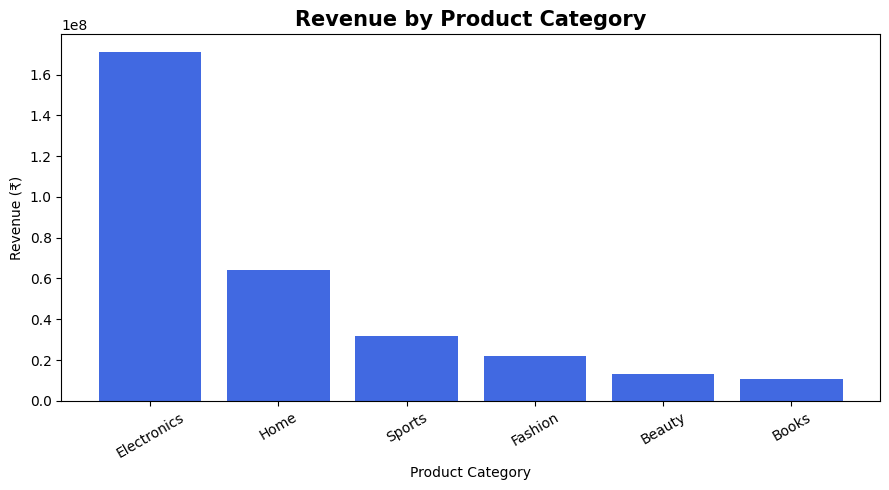

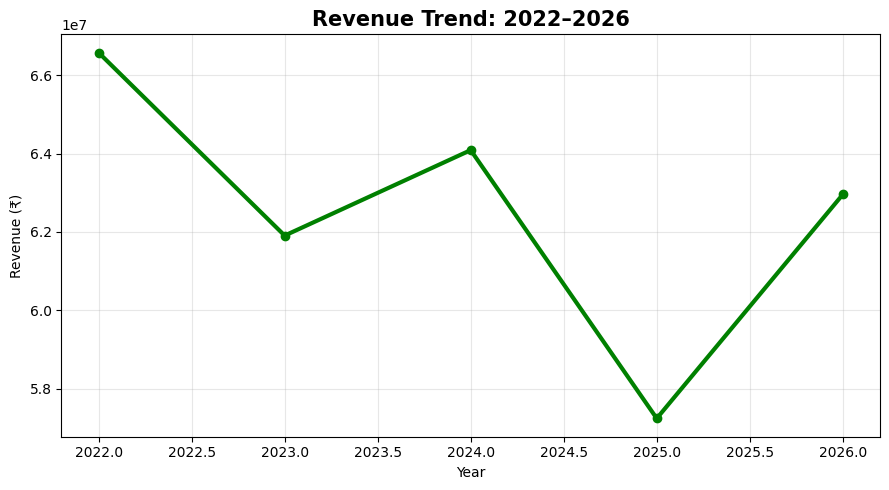

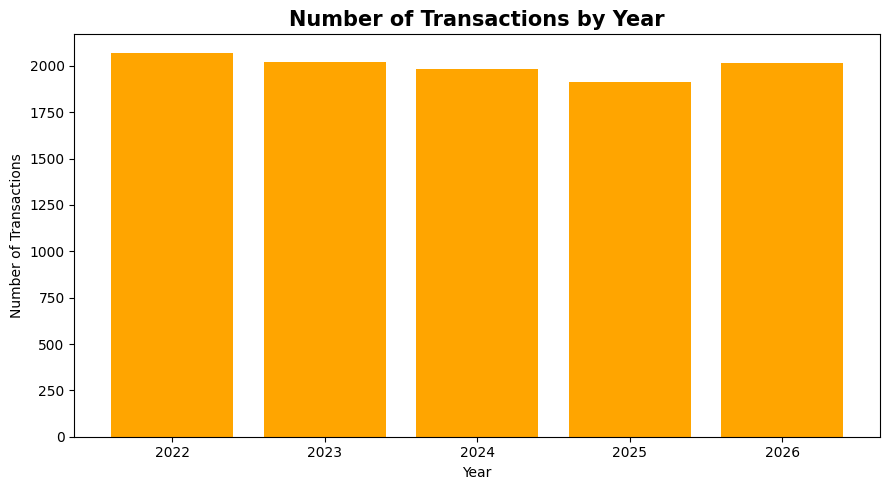

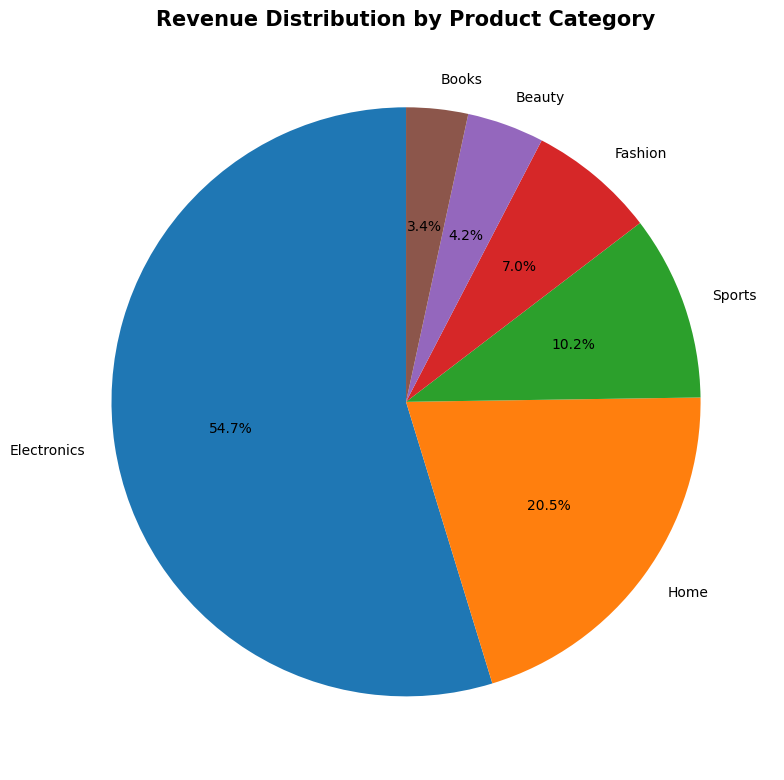

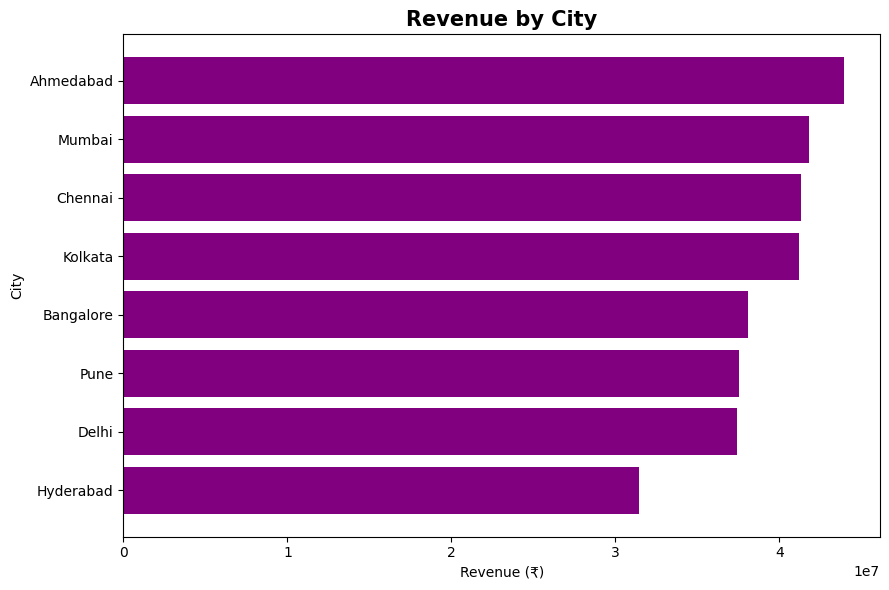

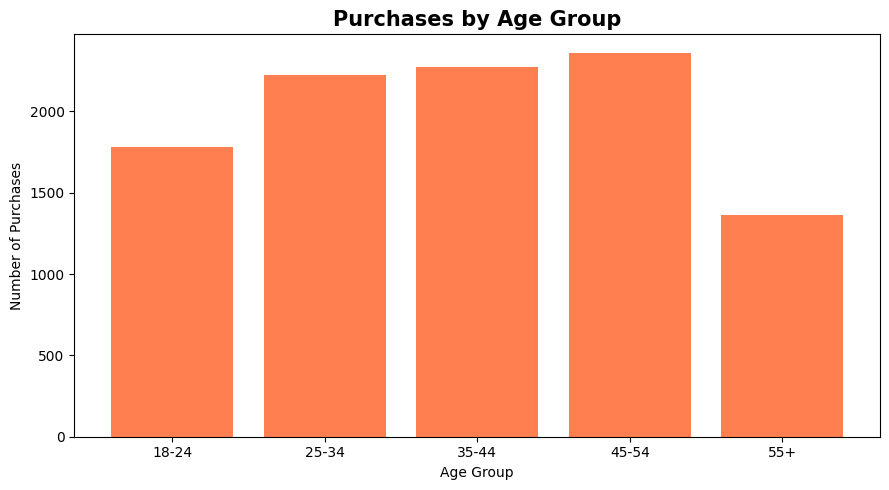

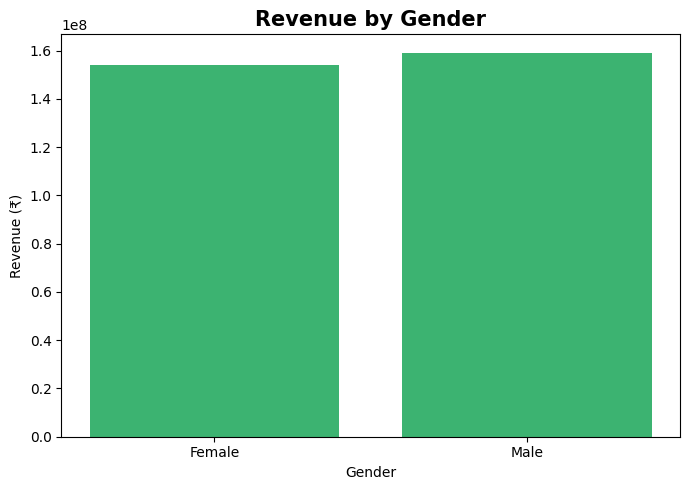

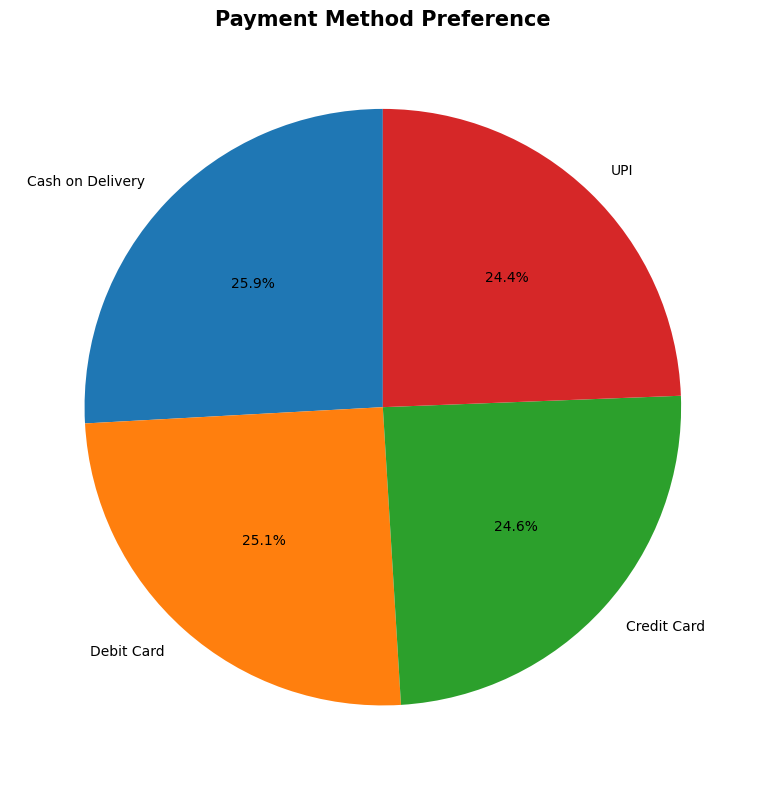

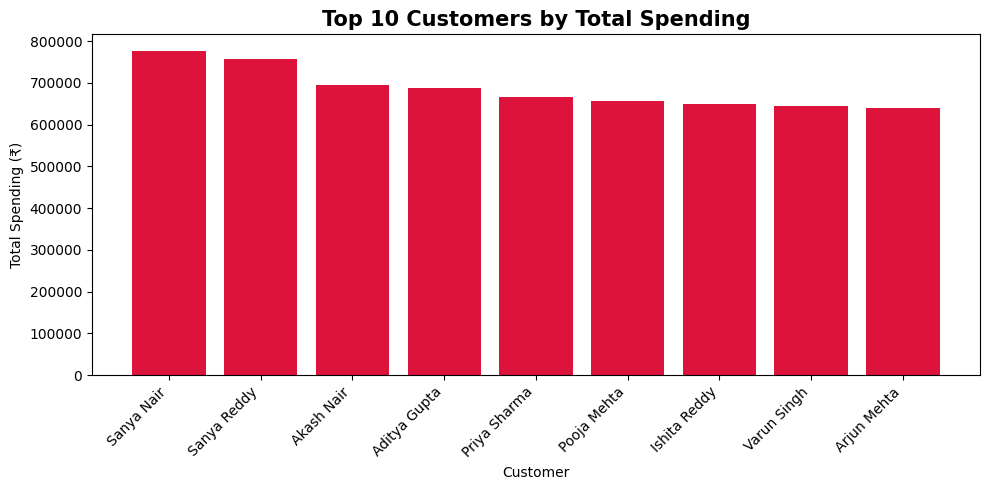

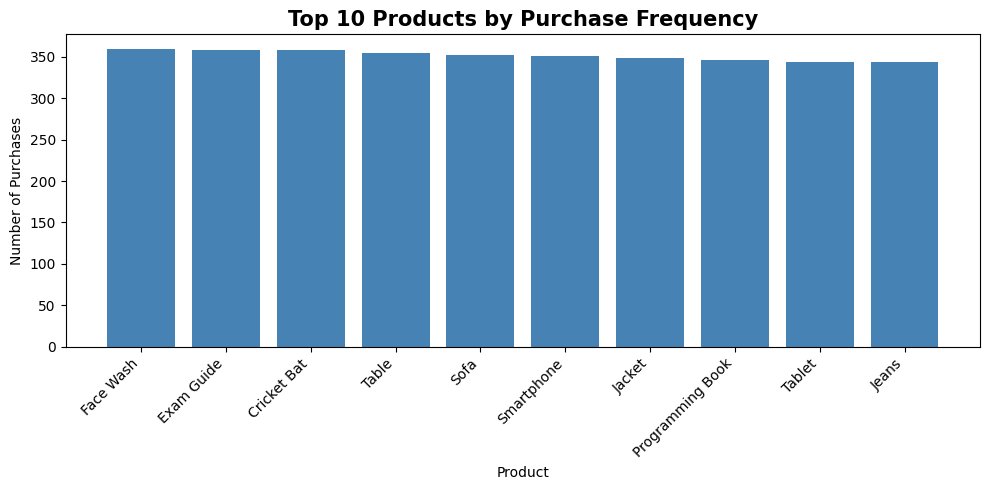

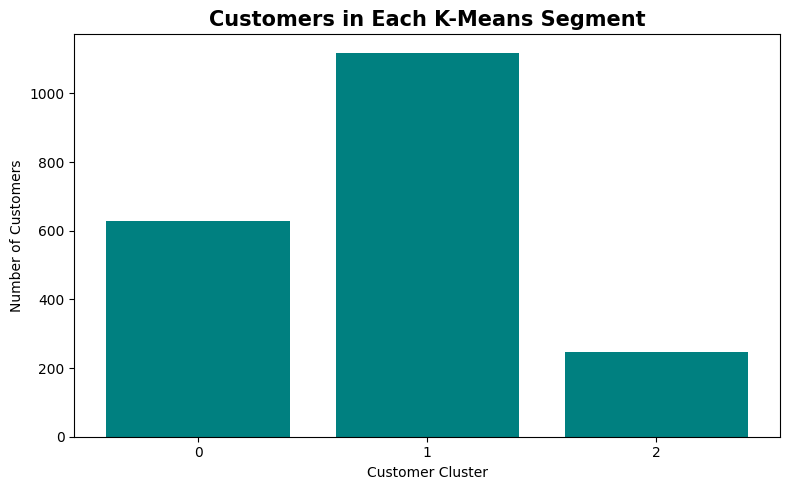

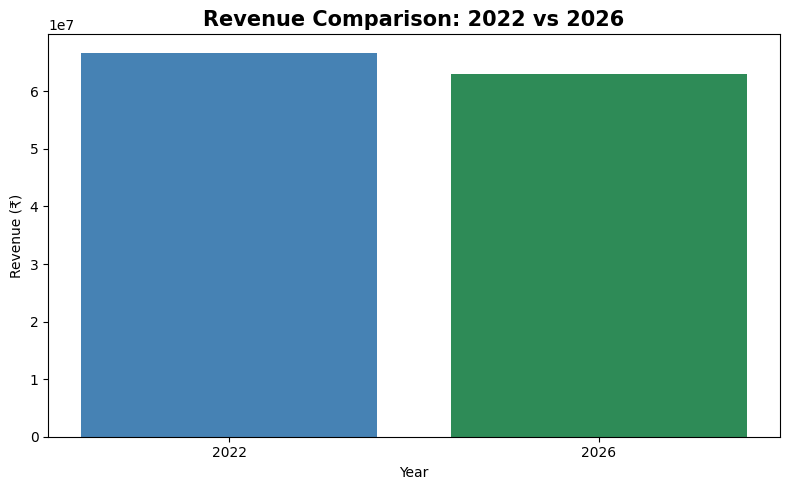

COMPLETE VISUALIZATION DASHBOARD GENERATED SUCCESSFULLY

Visualizations Generated:
1. Revenue by Product Category
2. Revenue Trend: 2022–2026
3. Transactions by Year
4. Category Revenue Distribution
5. Revenue by City
6. Purchases by Age Group
7. Revenue by Gender
8. Payment Method Preference
9. Top 10 Customers
10. Top 10 Products
11. K-Means Customer Segments
12. 2022 vs 2026 Revenue Comparison

Main processing: PySpark
Visualization: Matplotlib
Pandas used only for aggregated visualization data.


In [45]:
# ============================================================
# COMPLETE E-COMMERCE ANALYTICS VISUALIZATION DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("Preparing visualization data...")

# ============================================================
# CONVERT ONLY AGGREGATED SPARK DATA TO PANDAS
# ============================================================

year_pd = year_analysis.toPandas()

category_pd = category_analysis.toPandas()

city_pd = city_analysis.toPandas()

top_customers_pd = top_customers.limit(10).toPandas()

product_pd = product_analysis.limit(10).toPandas()

age_pd = age_analysis.toPandas()

gender_pd = gender_analysis.toPandas()

payment_pd = payment_analysis.toPandas()

cluster_pd = cluster_analysis.toPandas()


# ============================================================
# 1. REVENUE BY CATEGORY — BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    category_pd["Category"],
    category_pd["TotalRevenue"],
    color="royalblue"
)

plt.title(
    "Revenue by Product Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 2. REVENUE TREND 2022–2026 — LINE GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    year_pd["Year"],
    year_pd["TotalRevenue"],
    marker="o",
    linewidth=3,
    color="green"
)

plt.title(
    "Revenue Trend: 2022–2026",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue (₹)")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. TRANSACTIONS BY YEAR — BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    year_pd["Year"].astype(str),
    year_pd["NumberOfTransactions"],
    color="orange"
)

plt.title(
    "Number of Transactions by Year",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()


# ============================================================
# 4. CATEGORY REVENUE SHARE — PIE CHART
# ============================================================

plt.figure(figsize=(8, 8))

plt.pie(
    category_pd["TotalRevenue"],
    labels=category_pd["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Revenue Distribution by Product Category",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. CITY-WISE REVENUE — HORIZONTAL BAR
# ============================================================

city_sorted = city_pd.sort_values(
    "TotalRevenue",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    city_sorted["City"],
    city_sorted["TotalRevenue"],
    color="purple"
)

plt.title(
    "Revenue by City",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Revenue (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()


# ============================================================
# 6. AGE GROUP PURCHASES — BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    age_pd["AgeGroup"],
    age_pd["NumberOfPurchases"],
    color="coral"
)

plt.title(
    "Purchases by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Purchases")

plt.tight_layout()
plt.show()


# ============================================================
# 7. GENDER REVENUE — BAR CHART
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    gender_pd["Gender"],
    gender_pd["TotalRevenue"],
    color="mediumseagreen"
)

plt.title(
    "Revenue by Gender",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()


# ============================================================
# 8. PAYMENT METHOD — PIE CHART
# ============================================================

plt.figure(figsize=(8, 8))

plt.pie(
    payment_pd["NumberOfTransactions"],
    labels=payment_pd["PaymentMethod"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Payment Method Preference",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. TOP 10 CUSTOMERS — BAR CHART
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    top_customers_pd["CustomerName"],
    top_customers_pd["TotalSpent"],
    color="crimson"
)

plt.title(
    "Top 10 Customers by Total Spending",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer")
plt.ylabel("Total Spending (₹)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. TOP PRODUCTS — BAR CHART
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    product_pd["Product"],
    product_pd["NumberOfPurchases"],
    color="steelblue"
)

plt.title(
    "Top 10 Products by Purchase Frequency",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Number of Purchases")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. CUSTOMER SEGMENTS — BAR CHART
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_pd["Cluster"].astype(str),
    cluster_pd["NumberOfCustomers"],
    color="teal"
)

plt.title(
    "Customers in Each K-Means Segment",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 12. 2022 VS 2026 REVENUE COMPARISON
# ============================================================

comparison_pd = year_pd[
    year_pd["Year"].isin([2022, 2026])
]

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_pd["Year"].astype(str),
    comparison_pd["TotalRevenue"],
    color=["steelblue", "seagreen"]
)

plt.title(
    "Revenue Comparison: 2022 vs 2026",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()


# ============================================================
# FINAL MESSAGE
# ============================================================

print("=" * 70)
print("COMPLETE VISUALIZATION DASHBOARD GENERATED SUCCESSFULLY")
print("=" * 70)

print("""
Visualizations Generated:
1. Revenue by Product Category
2. Revenue Trend: 2022–2026
3. Transactions by Year
4. Category Revenue Distribution
5. Revenue by City
6. Purchases by Age Group
7. Revenue by Gender
8. Payment Method Preference
9. Top 10 Customers
10. Top 10 Products
11. K-Means Customer Segments
12. 2022 vs 2026 Revenue Comparison
""")

print("Main processing: PySpark")
print("Visualization: Matplotlib")
print("Pandas used only for aggregated visualization data.")

Final Summary

In [46]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

from pyspark.sql.functions import sum, avg, count

# Overall project metrics
total_transactions = df.count()

unique_customers = df.select(
    "CustomerID"
).distinct().count()

total_revenue = df.select(
    sum("TotalAmount")
).collect()[0][0]

average_order_value = df.select(
    avg("TotalAmount")
).collect()[0][0]

total_categories = df.select(
    "Category"
).distinct().count()

total_cities = df.select(
    "City"
).distinct().count()

total_products = df.select(
    "Product"
).distinct().count()


# Find highest revenue category
top_category = category_analysis.first()

# Find highest revenue city
top_city = city_analysis.first()

# Find most frequently used payment method
top_payment = payment_analysis.first()

# Find highest-value customer
top_customer = top_customers.first()


# ============================================================
# DISPLAY FINAL SUMMARY
# ============================================================

print("=" * 75)
print("        FLIPKART-INSPIRED E-COMMERCE CUSTOMER ANALYSIS")
print("=" * 75)

print("\nDATASET OVERVIEW")
print("-" * 75)

print("Analysis Period        : 2022 – 2026")
print("Dataset Type           : Synthetic / Simulated")
print("Total Transactions     :", total_transactions)
print("Unique Customers       :", unique_customers)
print("Product Categories     :", total_categories)
print("Products               :", total_products)
print("Cities Covered         :", total_cities)


print("\nOVERALL BUSINESS METRICS")
print("-" * 75)

print(
    "Total Simulated Revenue : ₹{:,.2f}".format(
        total_revenue
    )
)

print(
    "Average Order Value     : ₹{:,.2f}".format(
        average_order_value
    )
)


print("\nTOP BUSINESS INSIGHTS")
print("-" * 75)

print(
    "Highest Revenue Category :",
    top_category["Category"]
)

print(
    "Category Revenue         : ₹{:,.2f}".format(
        top_category["TotalRevenue"]
    )
)

print(
    "Highest Revenue City     :",
    top_city["City"]
)

print(
    "City Revenue             : ₹{:,.2f}".format(
        top_city["TotalRevenue"]
    )
)

print(
    "Most Used Payment Method :",
    top_payment["PaymentMethod"]
)

print(
    "Top Customer             :",
    top_customer["CustomerName"]
)

print(
    "Top Customer City        :",
    top_customer["City"]
)

print(
    "Top Customer Spending    : ₹{:,.2f}".format(
        top_customer["TotalSpent"]
    )
)


print("\nCUSTOMER SEGMENTATION")
print("-" * 75)

cluster_analysis.show()


print("\nPROJECT CONCLUSION")
print("-" * 75)

print("""
The project analyzes simulated e-commerce customer transactions
inspired by a Flipkart-like business environment from 2022 to 2026.

PySpark was used for data processing, cleaning, aggregation and
customer-level feature engineering.

Customer behaviour was analyzed using purchasing frequency,
total spending, average order value, age, gender, city, category
and payment method.

K-Means clustering was then applied to identify groups of customers
with similar purchasing behaviour.

The resulting analysis can help an e-commerce business understand
customer segments, identify high-value customers, study purchasing
patterns and support targeted marketing strategies.

All customer names, IDs, transactions and revenue values are
synthetically generated for academic demonstration and do not
represent actual Flipkart customer or financial data.
""")

print("=" * 75)
print("                 PROJECT COMPLETED")
print("=" * 75)

        FLIPKART-INSPIRED E-COMMERCE CUSTOMER ANALYSIS

DATASET OVERVIEW
---------------------------------------------------------------------------
Analysis Period        : 2022 – 2026
Dataset Type           : Synthetic / Simulated
Total Transactions     : 10000
Unique Customers       : 1991
Product Categories     : 6
Products               : 30
Cities Covered         : 8

OVERALL BUSINESS METRICS
---------------------------------------------------------------------------
Total Simulated Revenue : ₹312,771,279.00
Average Order Value     : ₹31,277.13

TOP BUSINESS INSIGHTS
---------------------------------------------------------------------------
Highest Revenue Category : Electronics
Category Revenue         : ₹171,196,658.00
Highest Revenue City     : Ahmedabad
City Revenue             : ₹43,935,137.00
Most Used Payment Method : Cash on Delivery
Top Customer             : Sanya Nair
Top Customer City        : Pune
Top Customer Spending    : ₹777,577.00

CUSTOMER SEGMENTATION
-------